# 1. add_noise

Add noise to a series with `nolitisea.noise.add_noise.add_noise`.

The input may be 1-D (a single series) or 2-D (one column per variable); every column receives its own independent noise realisation.  Five noise types are supported, and the meaning of `level` depends on the type:

- `"gaussian"` / `"colored"`: noise standard deviation relative to the per-column standard deviation (absolute when `absolute=True`);
- `"uniform"`: half-width of the distribution `[-level*std, +level*std]`;
- `"harmonic"`: scales the sinusoid amplitudes by `level * std`;
- `"impulse"`: unused (use `impulse_prob` and `impulse_amplitude`).

Each type is demonstrated below on a clean Lorenz trajectory.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.generate.lorenz import lorenz
from nolitisea.noise.add_noise import add_noise

# Clean Lorenz trajectory; every column is one scalar time series.
np.random.seed(0)
_, clean = lorenz(length=2000)
t = np.arange(clean.shape[0])
n = 500  # segment shown in the time-series plots

print(f"clean: shape {clean.shape}, per-column std {clean.std(axis=0).round(2)}")

clean: shape (2000, 3), per-column std [7.92 8.99 8.58]


## Gaussian and uniform noise

Both are white (uncorrelated).  With the same `level`, the uniform noise is bounded to `[-level*std, +level*std]` while the Gaussian one has unbounded tails, so at the same level the uniform noise looks slightly smaller.

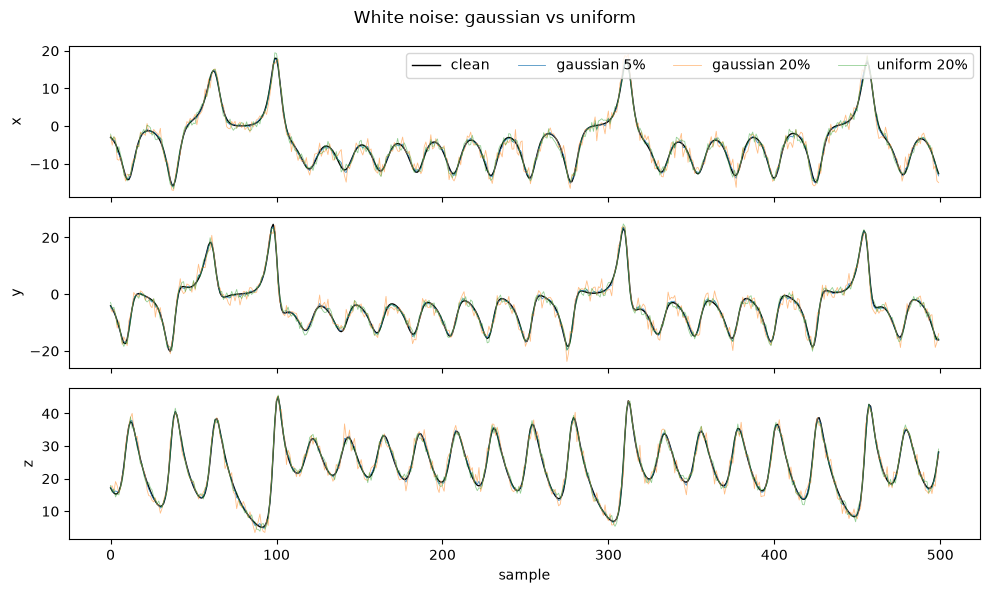

In [ ]:
g5 = add_noise(clean, noise_type="gaussian", level=0.05, seed=42)
g20 = add_noise(clean, noise_type="gaussian", level=0.20, seed=42)
u20 = add_noise(clean, noise_type="uniform", level=0.20, seed=42)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for j, (ax, name) in enumerate(zip(axes, "xyz")):
    ax.plot(t[:n], clean[:n, j], lw=1.0, color="black", label="clean")
    ax.plot(t[:n], g5[:n, j], lw=0.6, alpha=0.8, label="gaussian 5%")
    ax.plot(t[:n], g20[:n, j], lw=0.6, alpha=0.5, label="gaussian 20%")
    ax.plot(t[:n], u20[:n, j], lw=0.6, alpha=0.5, label="uniform 20%")
    ax.set_ylabel(name)
axes[0].legend(loc="upper right", ncols=4)
axes[-1].set_xlabel("sample")
fig.suptitle("White noise: gaussian vs uniform")

plt.tight_layout()
plt.show()

## Colored noise

`alpha` controls the power-law exponent of the noise spectrum: `alpha=0` gives white, `alpha=1` pink (flicker) and `alpha=2` red (Brownian) noise.  The realisations below are generated on a zero signal with `absolute=True` so the noise itself is visible, together with the periodograms confirming the `1/f^alpha` spectra.

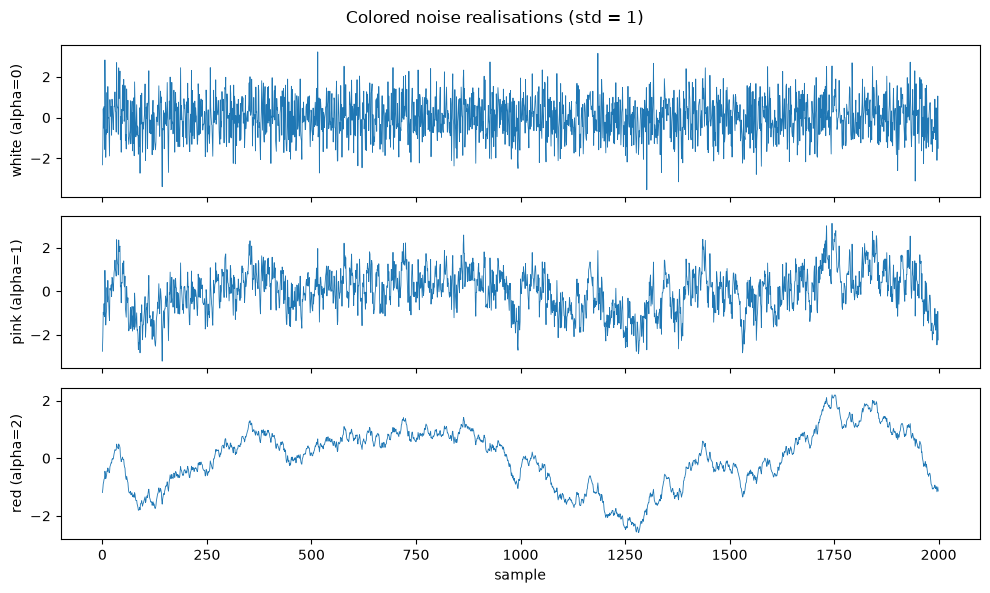

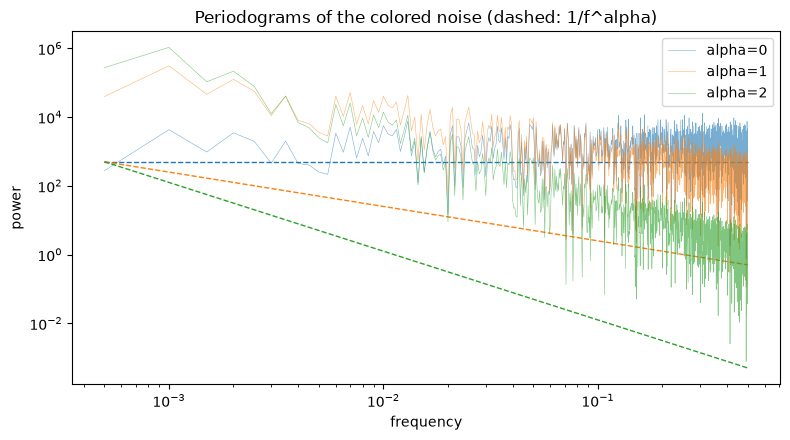

In [ ]:
alphas = [0.0, 1.0, 2.0]
labels = ["white (alpha=0)", "pink (alpha=1)", "red (alpha=2)"]

# Realisations on a zero signal, standard deviation 1.
noise_by_alpha = {
    a: add_noise(np.zeros(2000), noise_type="colored", level=1.0,
                 alpha=a, absolute=True, seed=7)
    for a in alphas
}

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, a, label in zip(axes, alphas, labels):
    ax.plot(t, noise_by_alpha[a], lw=0.6)
    ax.set_ylabel(label)
axes[-1].set_xlabel("sample")
fig.suptitle("Colored noise realisations (std = 1)")

plt.tight_layout()
plt.show()

# Periodograms with reference power-law slopes.
freq = np.fft.rfftfreq(2000)[1:]
fig, ax = plt.subplots(figsize=(8, 4.5))
for a, color in zip(alphas, ["C0", "C1", "C2"]):
    psd = np.abs(np.fft.rfft(noise_by_alpha[a])[1:]) ** 2
    ax.loglog(freq, psd, lw=0.4, alpha=0.6, color=color,
              label=f"alpha={a:.0f}")
    ax.loglog(freq, 5e2 * freq[0] ** a * freq ** (-a), ls="--",
              lw=1.0, color=color)
ax.set_xlabel("frequency")
ax.set_ylabel("power")
ax.set_title("Periodograms of the colored noise (dashed: 1/f^alpha)")
ax.legend()

plt.tight_layout()
plt.show()

## Harmonic and impulse noise

- `"harmonic"` adds a sum of sinusoids with the given `amplitudes`, `frequencies` (cycles per sample) and `phases`; `level` scales the amplitudes by `level * std(signal)`.
- `"impulse"` replaces each sample with probability `impulse_prob` by `+/- impulse_amplitude * std` (bipolar, default) or `+impulse_amplitude * std` ("salt").

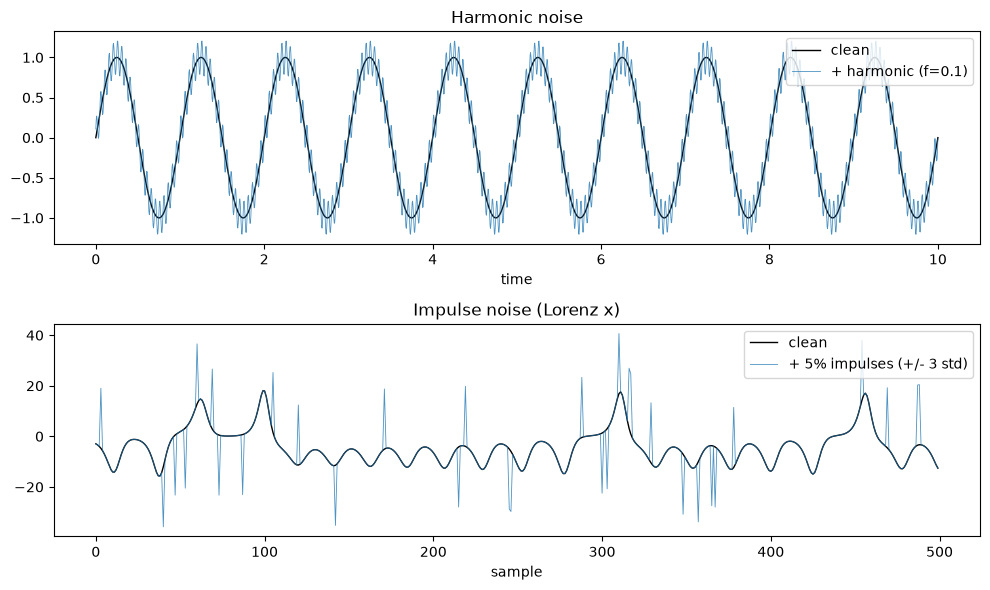

In [ ]:
# Harmonic noise on a smooth signal.
tt = np.linspace(0.0, 10.0, 2000)
signal = np.sin(2.0 * np.pi * tt)
harm = add_noise(
    signal, noise_type="harmonic", level=0.3,
    amplitudes=(1.0,), frequencies=(0.1,), seed=3,
)

# Impulse noise on the Lorenz x component.
imp = add_noise(
    clean[:, 0], noise_type="impulse",
    impulse_prob=0.05, impulse_amplitude=3.0, seed=11,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
axes[0].plot(tt, signal, lw=1.0, color="black", label="clean")
axes[0].plot(tt, harm, lw=0.6, alpha=0.8, label="+ harmonic (f=0.1)")
axes[0].set_xlabel("time")
axes[0].set_title("Harmonic noise")
axes[0].legend(loc="upper right")

axes[1].plot(t[:n], clean[:n, 0], lw=1.0, color="black", label="clean")
axes[1].plot(t[:n], imp[:n], lw=0.6, alpha=0.8,
             label="+ 5% impulses (+/- 3 std)")
axes[1].set_xlabel("sample")
axes[1].set_title("Impulse noise (Lorenz x)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

# 2. ghkss

Reduce noise with `nolitisea.noise.ghkss.ghkss`, the Grassberger-Hegger-Kantz-Schaffrath-Schreiber local-projection filter.

Each phase-space point is projected onto the `qdim` dominant eigendirections of its metric-weighted neighbourhood covariance; the orthogonal complement is treated as noise.  The input convention is `(n_times, comp)` — one column per component — matching the output of `lorenz` and `add_noise`.

In [ ]:
from nolitisea.noise.ghkss import ghkss

# Regenerate the clean trajectory and add 20% Gaussian noise.
np.random.seed(0)
_, clean = lorenz(length=2000)
noisy = add_noise(clean, noise_type='gaussian', level=0.20, seed=42)

# ghkss expects (n_times, comp): pass the noisy trajectory directly.
result = ghkss(noisy, embed=6, delay=1, qdim=3, minn=60, iterations=3)
corrected = result['corrected']  # same shape as noisy

# Quantify the noise reduction.
rms_noisy = np.sqrt(np.mean((noisy - clean) ** 2))
rms_corr = np.sqrt(np.mean((corrected - clean) ** 2))
print(f'RMS error (noisy)    : {rms_noisy:.4f}')
print(f'RMS error (corrected): {rms_corr:.4f}')
print(f'improvement          : {100 * (1 - rms_corr / rms_noisy):.1f}%')
for i, st in enumerate(result['stats']):
    avg = [round(v, 4) for v in st['average_shift']]
    rms = [round(v, 4) for v in st['rms_correction']]
    print(f'  iter {i+1}: avg_shift={avg}, rms_corr={rms}')

RMS error (noisy)    : 1.7067
RMS error (corrected): 1.2207
improvement          : 28.5%
  iter 1: avg_shift=[-0.0025, 0.0005, -0.0001], rms_corr=[0.487, 0.5677, 0.5205]


## Save the results

Write the noisy and corrected trajectories to text files for later analysis.

In [ ]:
from pathlib import Path

data_dir = Path('./data')
data_dir.mkdir(parents=True, exist_ok=True)

np.savetxt(data_dir / 'lorenz_noisy.txt', noisy, fmt='%.8f',
           header='Lorenz + 20% Gaussian noise; columns: x y z')
np.savetxt(data_dir / 'lorenz_corrected.txt', corrected, fmt='%.8f',
           header='Lorenz after GHKSS (embed=6, delay=1, qdim=3, '
                   'minn=60, iterations=3); columns: x y z')

print(f'saved {len(noisy)} samples to {data_dir}')

saved 2000 samples to data


## Time-series comparison

Clean, noisy and corrected signals overlaid for each component:

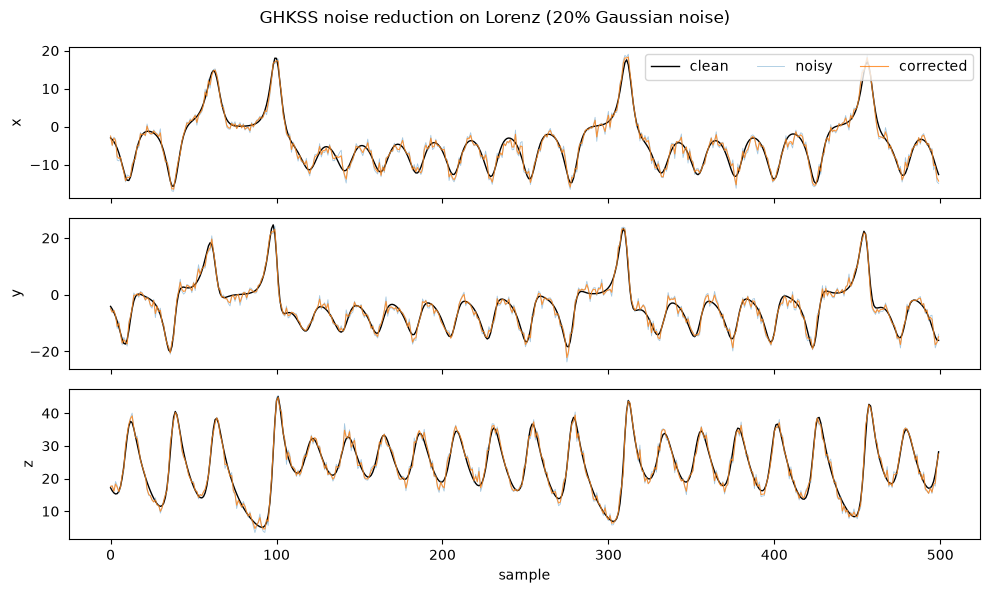

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for j, (ax, name) in enumerate(zip(axes, 'xyz')):
    ax.plot(t[:n], clean[:n, j], lw=1.0, color='black', label='clean')
    ax.plot(t[:n], noisy[:n, j], lw=0.6, alpha=0.4, label='noisy')
    ax.plot(t[:n], corrected[:n, j], lw=0.8, alpha=0.8, label='corrected')
    ax.set_ylabel(name)
axes[0].legend(loc='upper right', ncols=3)
axes[-1].set_xlabel('sample')
fig.suptitle('GHKSS noise reduction on Lorenz (20% Gaussian noise)')

plt.tight_layout()
plt.show()

## 3-D attractor comparison

The same data in phase space.  The noisy trajectory is scattered off the attractor; after GHKSS the trajectory returns close to the original manifold.

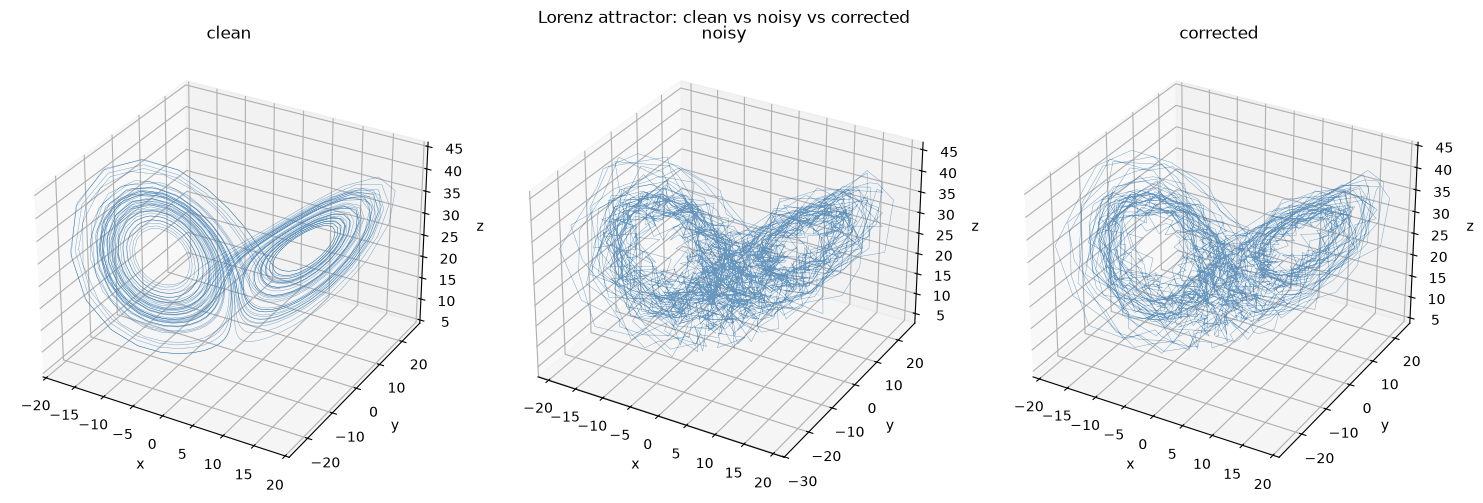

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                         subplot_kw={'projection': '3d'})
for ax, data, title in zip(
    axes, [clean, noisy, corrected],
    ['clean', 'noisy', 'corrected'],
):
    ax.plot(data[:, 0], data[:, 1], data[:, 2],
            lw=0.3, color='steelblue', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
fig.suptitle('Lorenz attractor: clean vs noisy vs corrected')

plt.tight_layout()
plt.show()